In [12]:
from fonctions_G2 import *
import pandas as pd

In [13]:
donnees_gse = 'Input_GSE.xlsx'

# Construction du taux r(t)

In [24]:
# Variables à fixer
r0 = 0.03
T = 10 
dt = 0.001  
N = int(T/dt)  
maturites = np.linspace(0, T, N)

# Paramètres à calibrer 
a = 4
b = 3 
sigma = 0.02  
eta = 0.03
rho = 0.3

Simulation des mouvements browniens

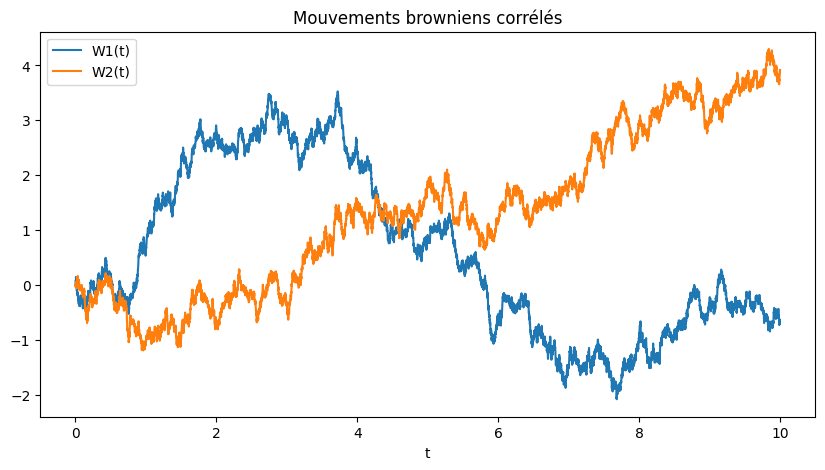

In [15]:
np.random.seed(42)

W1, W2 = mvts_browniens(T, dt, N, rho)

Génération de x(t) et y(t)

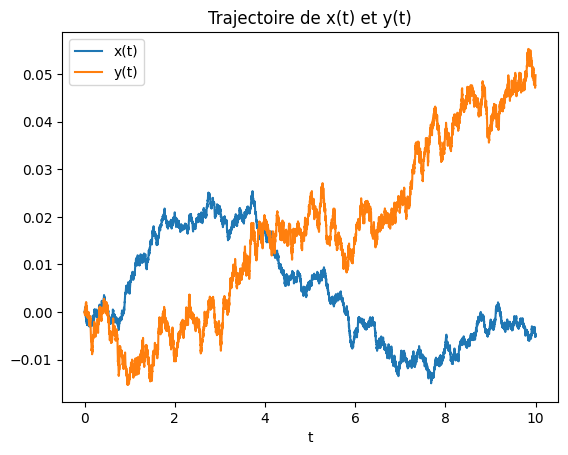

In [20]:
# Discrétisation d’un processus d’Ornstein-Uhlenbeck

x, y = parties_stochastiques(N, a, b, sigma, eta, W1, W2)

plt.plot(maturites, x, label = "x(t)")
plt.plot(maturites, y, label = "y(t)")
plt.legend()
plt.xlabel("t")
plt.title("Trajectoire de x(t) et y(t)")
plt.show()


Modélisation des taux forward par la méthode NSS (Nelson-Siegel-Svensson)

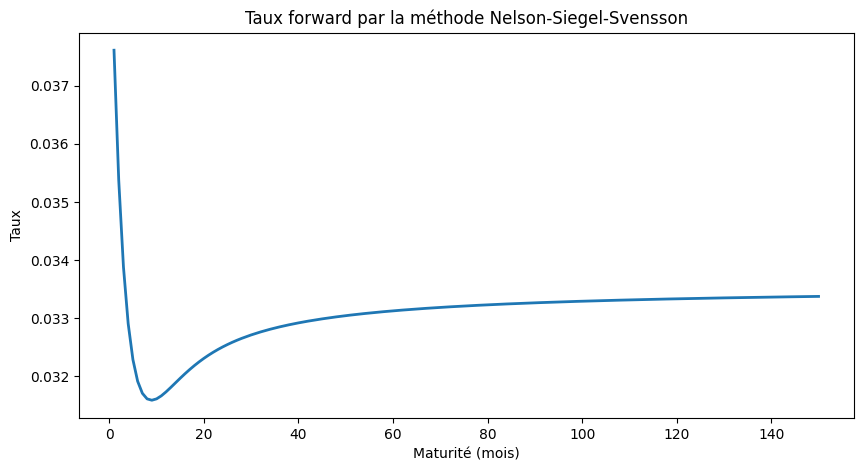

In [21]:
# Taux risque neutre : EIOPA
eiopa_rate = pd.read_excel(donnees_gse, sheet_name='EIOPA Rate')
eiopa_rate = pd.DataFrame(eiopa_rate.iloc[:, :2])
maturite_eiopa = eiopa_rate['Maturity']
taux = eiopa_rate['Rate']

# Initialisation
parametres = [0.1 , 0.1 , 0.1 , 0.1 , 1, 1]

parametres_NSS = NSS_optimisation(parametres, maturite_eiopa, taux)
taux_forward = forward_0t(maturite_eiopa, parametres_NSS.x)

plt.figure(figsize=(10, 5))
plt.plot(maturite_eiopa, taux_forward, linewidth=2)
plt.xlabel("Maturité (mois)")
plt.ylabel("Taux")
plt.title("Taux forward par la méthode Nelson-Siegel-Svensson")
plt.show()


Génération de phi(t)

In [18]:
# Initialisation
phi = np.zeros(N)
phi[0] = r0

for t in range(1, N): 
    phi[t] = partie_deterministe(t, sigma, eta, a, b, parametres_NSS.x)

Génération de r(t)

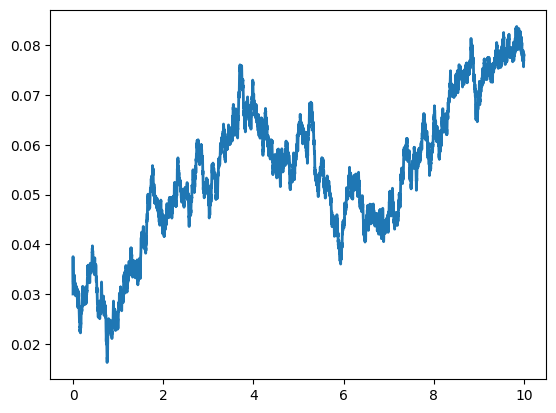

In [25]:
# Initialisation
r = np.zeros(N)
r[0] = r0


# r(t) : somme des deux processus stochastiques + processus déterministe
for t in range(1, N): 
    r[t] = x[t] + y[t] + phi[t]

plt.plot(maturites, r, linewidth=2)

# Princing d'une obligation zéro-coupon 